# MScFE 642 Deep Learning for Finance - Group Work Project #2 (17474)

# Rhushabh Vaghela
## India
## rhushabhvaghela@gmail.com

# Anubhav Sharma
## India
## anubhav.sharma1604@gmail.com

# Justice Kwame Appati
## Ghana
## jkappati@ug.edu.gh


This notebook follows the project requirements in order:

- Step 1: deliberately introduce information leakage and evaluate **MLP, LSTM, and CNN-GAF** using a single train/test split.
- Step 2: use the same three models in **non-anchored walk-forward backtests** with 500/500 and 500/100 train/test observations while retaining the deliberate leakage.
- Step 3: reduce leakage by using a strictly forward-looking target and fitting the feature scaler **inside each training window only**, then repeat the same walk-forward experiments.
- Trading-strategy results are reported for every model. Predictions are converted into a simple long/short signal and evaluated against the **actual next-period return**, with no transaction costs.

In [ ]:
!pip install -q --upgrade yfinance
!pip install -q pyts

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, Conv2D, MaxPooling2D, Flatten
from pyts.image import GramianAngularField

import warnings
import random
warnings.filterwarnings("ignore")

def set_reproducible_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)

set_reproducible_seeds(42)

ASSET = "AAPL"
START_DATE = "2018-01-01"
END_DATE = "2023-01-01"
SEQ_LENGTH = 10
STEP1_TRAIN_FRACTION = 0.80
WALK_FORWARD_TRAIN = 500
WALK_FORWARD_TEST_LARGE = 500
WALK_FORWARD_TEST_SMALL = 100
STEP1_EPOCHS = 10
WALK_FORWARD_EPOCHS = 5
BATCH_SIZE = 32

print("Configuration loaded successfully.")

Configuration loaded successfully.


# Step 1.a: Gather information on the time series of the prices

=== Step 1a. Gathering Time Series Data ===

[Data Summary]
- Asset Ticker: AAPL
- Data Range: 2018-01-03 to 2022-12-30
- Total observations after return calculation: 1258
- Columns gathered: ['Close', 'Return']
- Initial Price range: Min $35.55 | Max $182.01
- Mean daily return: 0.001101
- Daily return standard deviation: 0.021100


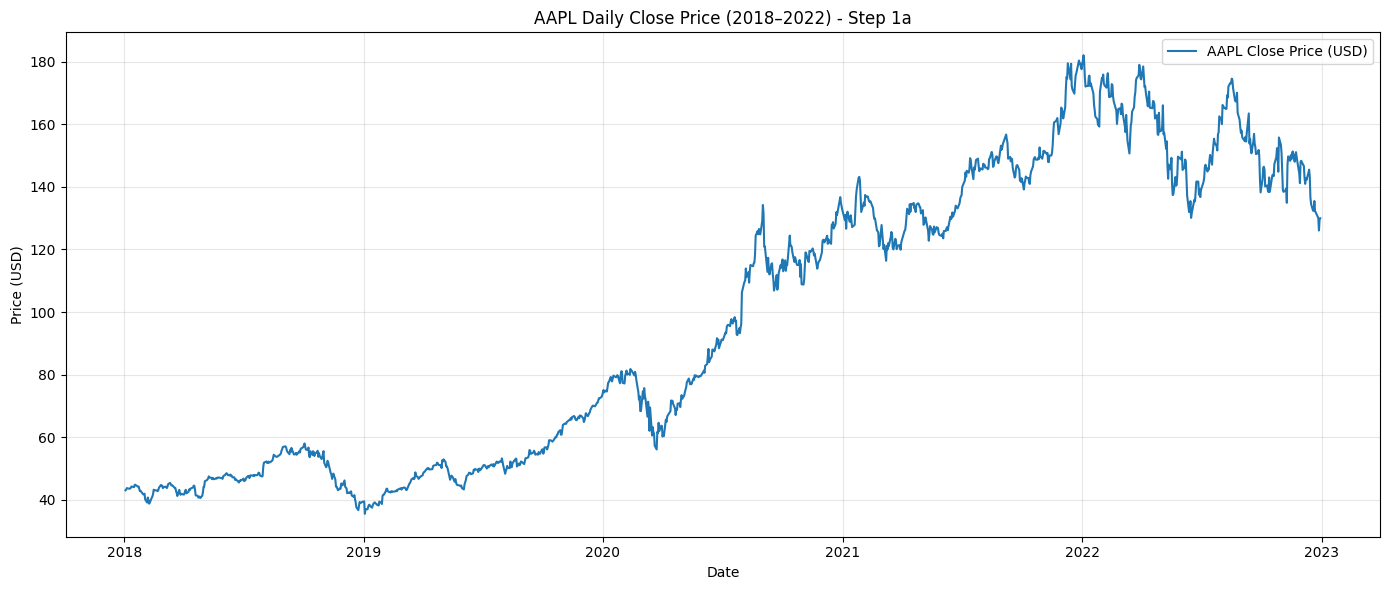

In [ ]:
print("=== Step 1a. Gathering Time Series Data ===")

raw = yf.download(
    ASSET, start=START_DATE, end=END_DATE,
    auto_adjust=False, progress=False
)

if isinstance(raw.columns, pd.MultiIndex):
    close = raw["Close"][ASSET]
else:
    close = raw["Close"]

data = pd.DataFrame({"Close": close}).dropna()
data["Return"] = data["Close"].pct_change()
data = data.dropna().copy()

print("\n[Data Summary]")
print(f"- Asset Ticker: {ASSET}")
print(f"- Data Range: {data.index.min().date()} to {data.index.max().date()}")
print(f"- Total observations after return calculation: {len(data)}")
print(f"- Columns gathered: {list(data.columns)}")
print(f"- Initial Price range: Min ${data['Close'].min():.2f} | Max ${data['Close'].max():.2f}")
print(f"- Mean daily return: {data['Return'].mean():.6f}")
print(f"- Daily return standard deviation: {data['Return'].std():.6f}")

if len(data) >= 2000:
    raise ValueError("The project requires no more than 2,000 observations.")

plt.figure(figsize=(14, 6))
plt.plot(data.index, data["Close"], label=f"{ASSET} Close Price (USD)", linewidth=1.5)
plt.title("AAPL Daily Close Price (2018–2022) - Step 1a")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of Results

- The dataset contains 1,258 daily observations of Apple Inc. (AAPL) from January 3, 2018 through December 30, 2022. This satisfies the project requirement that the selected time series contain no more than 2,000 observations.

- During the sample period, AAPL's closing price ranged from approximately $35.55 to $182.01. The average daily return was approximately 0.11%, while the daily return standard deviation was approximately 2.11%. The relatively small average return compared with the daily volatility illustrates the noisy nature of daily stock returns and provides an appropriate setting for examining the robustness of predictive models under different validation designs.

- The substantial variation in the price and return series provides motivation for using walk-forward validation to examine whether model performance remains stable across different historical periods. This makes the subsequent walk-forward validation particularly relevant.

# Step 1.b: Build the model's labels to explicitly introduce information leakage

Two deliberate leakage mechanisms are used:

1. **Leaky target:** a centered five-observation moving average is shifted so that the target at time *t* contains future returns.
2. **Global feature scaling:** the scaler is fitted on the complete return series before the train/test split, allowing future test-period information to influence the transformation used for training observations.

The purpose is to create the deliberately contaminated validation design requested by the project so that Step 2 can be compared with Step 3 after leakage mitigation.

In [ ]:
print("=== Step 1b. Introducing Information Leakage ===")

leaky_data = data.copy()
leaky_data["Target_Leaky"] = (
    leaky_data["Return"].rolling(window=5, center=True).mean().shift(-1)
)
leaky_data["Actual_Next_Return"] = leaky_data["Return"].shift(-1)
leaky_data = leaky_data.dropna(subset=["Target_Leaky", "Actual_Next_Return"]).copy()

# Deliberate global look-ahead in the feature scaling.
scaler_leaky = MinMaxScaler()
leaky_data["Scaled_Return_Leaky"] = scaler_leaky.fit_transform(leaky_data[["Return"]])

def create_sequences(features, targets, seq_length):
    X, y = [], []
    for i in range(len(features) - seq_length + 1):
        X.append(features[i:i + seq_length])
        y.append(targets[i + seq_length - 1])
    return np.asarray(X), np.asarray(y)

def create_sequences_with_actual(features, targets, actual_returns, seq_length):
    X, y, actual = [], [], []
    for i in range(len(features) - seq_length + 1):
        target_index = i + seq_length - 1
        X.append(features[i:i + seq_length])
        y.append(targets[target_index])
        actual.append(actual_returns[target_index])
    return np.asarray(X), np.asarray(y), np.asarray(actual)

X_leaky, y_leaky, actual_next_leaky = create_sequences_with_actual(
    leaky_data["Scaled_Return_Leaky"].values,
    leaky_data["Target_Leaky"].values,
    leaky_data["Actual_Next_Return"].values,
    SEQ_LENGTH
)

split_idx = int(len(X_leaky) * STEP1_TRAIN_FRACTION)
X_train_l, X_test_l = X_leaky[:split_idx], X_leaky[split_idx:]
y_train_l, y_test_l = y_leaky[:split_idx], y_leaky[split_idx:]
actual_next_test_l = actual_next_leaky[split_idx:]

print(f"- Total rows after leaky target engineering: {len(leaky_data)}")
print(f"- Sequence length: {SEQ_LENGTH}")
print(f"- X_leaky shape: {X_leaky.shape}")
print(f"- y_leaky shape: {y_leaky.shape}")
print(f"- Train/Test split: {STEP1_TRAIN_FRACTION:.0%} / {1-STEP1_TRAIN_FRACTION:.0%}")
print(f"- X_train_l shape: {X_train_l.shape} | y_train_l shape: {y_train_l.shape}")
print(f"- X_test_l shape: {X_test_l.shape} | y_test_l shape: {y_test_l.shape}")
print(f"- Global scaling boundaries: min={scaler_leaky.data_min_[0]:.6f}, max={scaler_leaky.data_max_[0]:.6f}")
print("  NOTE: these limits were fitted before the split, so future test-period information is included.")
print("\n[Leakage]")
print("- Target_Leaky is a centered rolling quantity shifted by one period, so it depends on future observations relative to the prediction date.")

=== Step 1b. Introducing Information Leakage ===
- Total rows after leaky target engineering: 1254
- Sequence length: 10
- X_leaky shape: (1245, 10)
- y_leaky shape: (1245,)
- Train/Test split: 80% / 20%
- X_train_l shape: (996, 10) | y_train_l shape: (996,)
- X_test_l shape: (249, 10) | y_test_l shape: (249,)
- Global scaling boundaries: min=-0.128647, max=0.119808
  NOTE: these limits were fitted before the split, so future test-period information is included.

[Leakage]
- Target_Leaky is a centered rolling quantity shifted by one period, so it depends on future observations relative to the prediction date.


### Interpretation of Results

The Step 1b construction deliberately introduces information leakage into the predictive experiment in two ways.

- First, the target is constructed using a centered moving average. Because a centered rolling calculation uses observations on both sides of the current observation, the resulting target incorporates information from future periods. Consequently, the target is not a valid information set for a real-time forecasting strategy.

- Second, the MinMaxScaler is fitted using the complete return series before the train/test split. Therefore, information from the future test period influences the scaling transformation applied to the training observations.

These procedures intentionally create the contaminated validation environment required by the project. The purpose is to establish a baseline against which the progressively stricter validation procedures in Steps 2 and 3 can be compared.

# Step 1.c: Use three DL models to predict the time series

Required architectures are implemented:

1. MLP
2. LSTM
3. CNN based on Gramian Angular Fields (GAF)

The same three model families are used again in Step 2 and Step 3 so that the validation comparison is meaningful.


## Trading-strategy definition

- predicted return >= 0 → long (+1)
- predicted return < 0 → short (-1)
- strategy return = position × actual next-period return

=== Step 1c. Building, Training, and Evaluating Models (Single Split) ===

[1/3] Training Multi-Layer Perceptron (MLP)...
[2/3] Training Long Short-Term Memory (LSTM)...
[3/3] Transforming sequences using GAF and training CNN...



[Data Format]
- MLP/LSTM train shape: (996, 10)
- MLP/LSTM test shape: (249, 10)
- GAF train shape: (996, 10, 10, 1)
- GAF test shape: (249, 10, 10, 1)

[Step 1c Results]


,Model,MSE,MAE,Directional Accuracy,Average Cumulative Strategy Return Across Folds,Annualized Sharpe,Max Drawdown,Average Daily Strategy Return
0,MLP,0.000079,0.006965,49.80%,-32.31%,-0.926,-40.19%,-0.00131
1,LSTM,0.000064,0.006421,47.39%,-29.36%,-0.805,-41.53%,-0.00114
2,CNN-GAF,0.000527,0.017367,44.18%,-48.79%,-1.726,-55.31%,-0.00243



Interpretation note: MSE and MAE are measured against the intentionally leaky target. Directional accuracy and trading-strategy performance are evaluated against the actual next-period return.


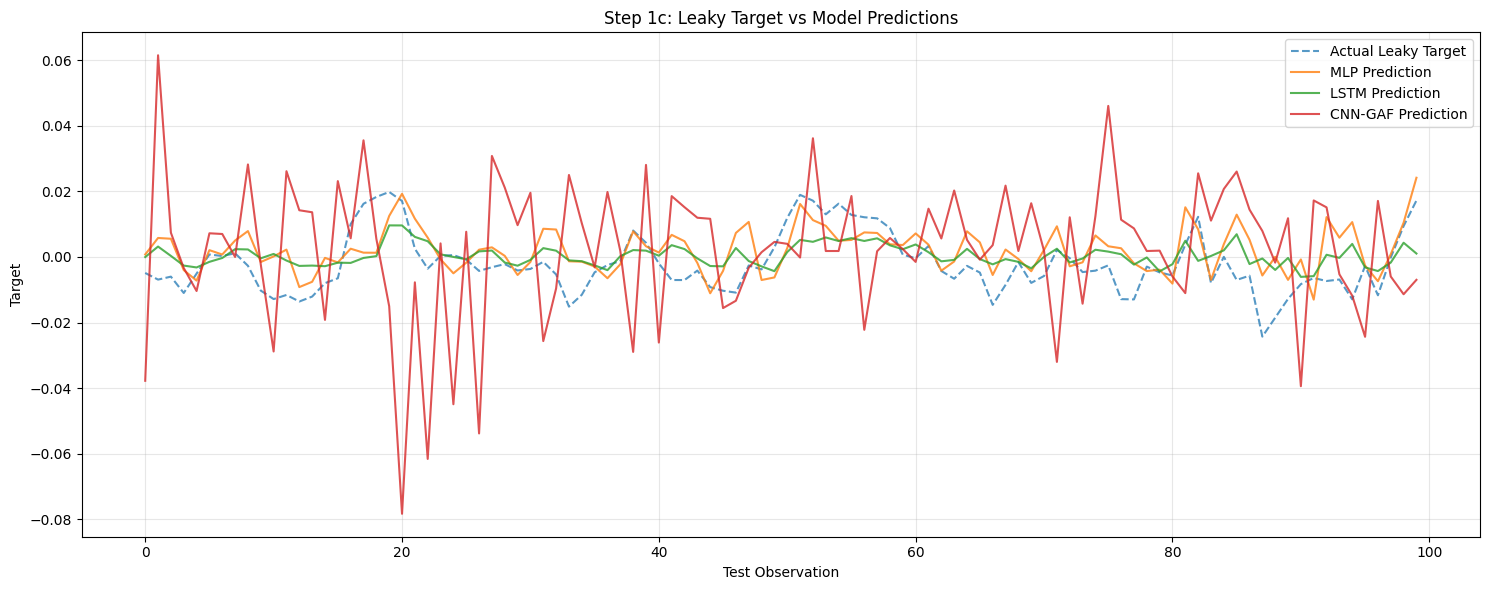

In [ ]:
print("=== Step 1c. Building, Training, and Evaluating Models (Single Split) ===")

def build_mlp(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Flatten(),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1, activation="linear")
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(32, return_sequences=False),
        Dense(16, activation="relu"),
        Dense(1, activation="linear")
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_cnn_gaf(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(16, kernel_size=(3, 3), activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(16, activation="relu"),
        Dense(1, activation="linear")
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def prepare_gaf(X_train, X_test):
    gaf = GramianAngularField(image_size=SEQ_LENGTH, method="summation")
    train_gaf = gaf.fit_transform(X_train.reshape(-1, SEQ_LENGTH))
    test_gaf = gaf.transform(X_test.reshape(-1, SEQ_LENGTH))
    train_gaf = train_gaf.reshape(-1, SEQ_LENGTH, SEQ_LENGTH, 1)
    test_gaf = test_gaf.reshape(-1, SEQ_LENGTH, SEQ_LENGTH, 1)
    return train_gaf, test_gaf

def directional_accuracy(y_true, y_pred):
    return float(np.mean(np.sign(np.asarray(y_true).flatten()) == np.sign(np.asarray(y_pred).flatten())))

def max_drawdown(return_series):
    equity = (1.0 + pd.Series(return_series)).cumprod()
    drawdown = equity / equity.cummax() - 1.0
    return float(drawdown.min())

def trading_metrics(predictions, actual_next_returns):
    predictions = np.asarray(predictions).flatten()
    actual_next_returns = np.asarray(actual_next_returns).flatten()
    positions = np.where(predictions >= 0, 1.0, -1.0) # predicted return >= 0 → long (+1) or else short (-1)
    strategy_returns = positions * actual_next_returns
    cumulative_return = float(np.prod(1.0 + strategy_returns) - 1.0)
    mean_ret = np.mean(strategy_returns)
    std_ret = np.std(strategy_returns, ddof=1)
    sharpe = float(np.sqrt(252) * mean_ret / std_ret) if std_ret > 0 else np.nan
    return {
        "Directional Accuracy": directional_accuracy(actual_next_returns, predictions),
        "Average Cumulative Strategy Return Across Folds": cumulative_return,
        "Annualized Sharpe": sharpe,
        "Max Drawdown": max_drawdown(strategy_returns),
        "Average Daily Strategy Return": float(mean_ret)
    }

def regression_metrics(y_true, y_pred):
    return {
        "MSE": float(mean_squared_error(y_true, y_pred)),
        "MAE": float(mean_absolute_error(y_true, y_pred))
    }

def build_model_by_name(model_name):
    if model_name == "MLP":
        return build_mlp((SEQ_LENGTH, 1))
    if model_name == "LSTM":
        return build_lstm((SEQ_LENGTH, 1))
    if model_name == "CNN-GAF":
        return build_cnn_gaf((SEQ_LENGTH, SEQ_LENGTH, 1))
    raise ValueError(f"Unknown model: {model_name}")

def prepare_inputs_for_model(model_name, X_train, X_test):
    if model_name == "CNN-GAF":
        return prepare_gaf(X_train, X_test)
    return X_train.reshape(-1, SEQ_LENGTH, 1), X_test.reshape(-1, SEQ_LENGTH, 1)

print("\n[1/3] Training Multi-Layer Perceptron (MLP)...")
set_reproducible_seeds(42)
mlp = build_mlp((SEQ_LENGTH, 1))
mlp.fit(X_train_l, y_train_l, epochs=STEP1_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
mlp_pred = mlp.predict(X_test_l, verbose=0).flatten()

print("[2/3] Training Long Short-Term Memory (LSTM)...")
set_reproducible_seeds(42)
lstm = build_lstm((SEQ_LENGTH, 1))
lstm.fit(X_train_l, y_train_l, epochs=STEP1_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
lstm_pred = lstm.predict(X_test_l, verbose=0).flatten()

print("[3/3] Transforming sequences using GAF and training CNN...")
X_train_gaf, X_test_gaf = prepare_gaf(X_train_l, X_test_l)
set_reproducible_seeds(42)
cnn = build_cnn_gaf((SEQ_LENGTH, SEQ_LENGTH, 1))
cnn.fit(X_train_gaf, y_train_l, epochs=STEP1_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
cnn_pred = cnn.predict(X_test_gaf, verbose=0).flatten()

print("\n[Data Format]")
print(f"- MLP/LSTM train shape: {X_train_l.shape}")
print(f"- MLP/LSTM test shape: {X_test_l.shape}")
print(f"- GAF train shape: {X_train_gaf.shape}")
print(f"- GAF test shape: {X_test_gaf.shape}")

step1_results = []
for name, pred in [("MLP", mlp_pred), ("LSTM", lstm_pred), ("CNN-GAF", cnn_pred)]:
    step1_results.append({"Model": name, **regression_metrics(y_test_l, pred), **trading_metrics(pred, actual_next_test_l)})
step1_results_df = pd.DataFrame(step1_results)

print("\n[Step 1c Results]")
display(step1_results_df.style.format({
    "MSE": "{:.6f}", "MAE": "{:.6f}", "Directional Accuracy": "{:.2%}",
    "Average Cumulative Strategy Return Across Folds": "{:.2%}", "Annualized Sharpe": "{:.3f}",
    "Max Drawdown": "{:.2%}", "Average Daily Strategy Return": "{:.5f}"
}))

print("\nInterpretation note: MSE and MAE are measured against the intentionally leaky target. Directional accuracy and trading-strategy performance are evaluated against the actual next-period return.")

plot_n = min(100, len(y_test_l))
plt.figure(figsize=(15, 6))
plt.plot(y_test_l[:plot_n], label="Actual Leaky Target", linestyle="--", alpha=0.75)
plt.plot(mlp_pred[:plot_n], label="MLP Prediction", alpha=0.8)
plt.plot(lstm_pred[:plot_n], label="LSTM Prediction", alpha=0.8)
plt.plot(cnn_pred[:plot_n], label="CNN-GAF Prediction", alpha=0.8)
plt.title("Step 1c: Leaky Target vs Model Predictions")
plt.xlabel("Test Observation")
plt.ylabel("Target")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation of Results

- The single-split experiment produces different results across the three architectures. All three models have directional accuracy below 50% and negative trading-strategy returns in this test sample. The MLP achieves 49.80% directional accuracy, followed by the LSTM at 47.39% and the CNN-GAF at 44.18%.

- The trading results are also negative for all three models, with cumulative strategy returns of -32.31% for the MLP, -29.36% for the LSTM, and -48.79% for the CNN-GAF. The corresponding Sharpe ratios are negative for all three models.

- These results demonstrate that model architecture can materially affect predictive and trading performance under a single train/test split. However, because the experiment intentionally contains information leakage and uses only one test period, these results should not be interpreted as evidence of persistent out-of-sample performance.

- The trading results reinforce the importance of evaluating both predictive accuracy and the resulting investment strategy. A model can have different prediction errors without producing a consistently profitable trading strategy.

- Because the Step 1 experiment deliberately contains leakage, its results should be regarded as a contaminated baseline rather than as an estimate of genuine out-of-sample performance.

# Step 2: Backtest the models using a walk-forward method

The project requires a **non-anchored walk-forward** design:

- Step 2a: 500 observations for training and 500 observations for testing.
- Step 2b: 500 observations for training and 100 observations for testing.

The leakage is intentionally retained in Step 2. Every fold rebuilds and retrains all three models. Ten historical observations immediately before each test window are used only as sequence context, so each fold still has exactly 500 or 100 test targets.

### Note on the 500/500 Walk-Forward Configuration

Only one complete 500/500 fold is possible because the selected dataset contains approximately 1,250 observations. The 500/100 configuration permits seven non-anchored folds.

Therefore, the 500/500 results should be interpreted as one complete out-of-sample test period, whereas the 500/100 configuration provides multiple rolling test periods and allows greater assessment of performance stability over time.

In [ ]:
def run_walk_forward_leaky(leaky_df, train_size, test_size):
    records, fold_details = [], []
    max_start = len(leaky_df) - train_size - test_size
    if max_start < 0:
        raise ValueError("Not enough observations for the requested split.")
    starts = list(range(0, max_start + 1, test_size))

    for fold_no, start in enumerate(starts, start=1):
        train_start, train_end = start, start + train_size
        test_start, test_end = train_end, train_end + test_size
        train_slice = leaky_df.iloc[train_start:train_end].copy()
        test_context_start = max(0, test_start - SEQ_LENGTH)
        test_context = leaky_df.iloc[test_context_start:test_end].copy()

        X_train, y_train = create_sequences(
            train_slice["Scaled_Return_Leaky"].values,
            train_slice["Target_Leaky"].values, SEQ_LENGTH
        )
        X_test, y_test, actual_test_returns = create_sequences_with_actual(
            test_context["Scaled_Return_Leaky"].values,
            test_context["Target_Leaky"].values,
            test_context["Actual_Next_Return"].values, SEQ_LENGTH
        )

        # The first sequence ends at the final training observation.
        # Keeping only sequences whose target belongs to the test period.
        X_test = X_test[1:]
        y_test = y_test[1:]
        actual_test_returns = actual_test_returns[1:]

        if len(X_test) != test_size:
            raise ValueError(f"Expected {test_size} test sequences but received {len(X_test)}.")

        for model_name in ["MLP", "LSTM", "CNN-GAF"]:
            set_reproducible_seeds(42 + fold_no)
            X_train_model, X_test_model = prepare_inputs_for_model(model_name, X_train, X_test)
            model = build_model_by_name(model_name)
            model.fit(X_train_model, y_train, epochs=WALK_FORWARD_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            predictions = model.predict(X_test_model, verbose=0).flatten()
            records.append({
                "Fold": fold_no, "Model": model_name,
                "Train Start": train_start, "Train End": train_end - 1,
                "Test Start": test_start, "Test End": test_end - 1,
                **regression_metrics(y_test, predictions),
                **trading_metrics(predictions, actual_test_returns)
            })

        fold_details.append({
            "Fold": fold_no, "Train Start": train_start, "Train End": train_end - 1,
            "Test Start": test_start, "Test End": test_end - 1
        })
    return pd.DataFrame(records), pd.DataFrame(fold_details)

print("=== Step 2a. Walk-forward backtest (Train 500, Test 500) - Leaky ===")
step2a_df, step2a_folds = run_walk_forward_leaky(leaky_data, 500, 500)
display(step2a_folds)
display(step2a_df.style.format({
    "MSE":"{:.6f}", "MAE":"{:.6f}", "Directional Accuracy":"{:.2%}",
    "Average Cumulative Strategy Return Across Folds":"{:.2%}", "Annualized Sharpe":"{:.3f}",
    "Max Drawdown":"{:.2%}", "Average Daily Strategy Return":"{:.5f}"
}))

=== Step 2a. Walk-forward backtest (Train 500, Test 500) - Leaky ===


,Fold,Train Start,Train End,Test Start,Test End
0,1,0,499,500,999


,Fold,Model,Train Start,Train End,Test Start,Test End,MSE,MAE,Directional Accuracy,Average Cumulative Strategy Return Across Folds,Annualized Sharpe,Max Drawdown,Average Daily Strategy Return
0,1,MLP,0,499,500,999,0.000164,0.009045,47.80%,-25.63%,-0.206,-48.55%,-0.00031
1,1,LSTM,0,499,500,999,0.000068,0.006008,50.80%,-27.39%,-0.236,-61.66%,-0.00035
2,1,CNN-GAF,0,499,500,999,0.000107,0.007688,51.80%,-23.73%,-0.173,-46.04%,-0.00026


### Interpretation of Results

- The 500/500 non-anchored walk-forward experiment produces different results from the single-split experiment. The MLP achieves 47.80% directional accuracy, while the LSTM and CNN-GAF achieve 50.80% and 51.80%, respectively.

- Despite the directional accuracy above 50% for the LSTM and CNN-GAF, all three trading strategies generate negative cumulative returns during this test period: -25.63% for the MLP, -27.39% for the LSTM, and -23.73% for the CNN-GAF. All three Sharpe ratios are also negative.

- This illustrates that directional accuracy alone does not guarantee profitable trading performance. Transaction costs are not included in this experiment, so the negative results arise before accounting for additional trading frictions.

- Only one complete 500/500 walk-forward fold can be formed from the available dataset. Therefore, these results represent one out-of-sample test period and should not be interpreted as evidence of stable performance across multiple market regimes.

- Compared with Step 1, the walk-forward procedure changes the test period and validation design, demonstrating why results from a single historical split should be interpreted cautiously.

In [ ]:
print("\n=== Step 2b. Walk-forward backtest (Train 500, Test 100) - Leaky ===")
step2b_df, step2b_folds = run_walk_forward_leaky(leaky_data, 500, 100)
display(step2b_folds)
display(step2b_df.style.format({
    "MSE":"{:.6f}", "MAE":"{:.6f}", "Directional Accuracy":"{:.2%}",
    "Average Cumulative Strategy Return Across Folds":"{:.2%}", "Annualized Sharpe":"{:.3f}",
    "Max Drawdown":"{:.2%}", "Average Daily Strategy Return":"{:.5f}"
}))

step2_summary = step2b_df.groupby("Model").agg({
    "Directional Accuracy":"mean", "Average Cumulative Strategy Return Across Folds":"mean",
    "Annualized Sharpe":"mean", "Max Drawdown":"mean"
}).reset_index()
print("\nStep 2b average results across folds:")
display(step2_summary.style.format({
    "Directional Accuracy":"{:.2%}", "Average Cumulative Strategy Return Across Folds":"{:.2%}",
    "Annualized Sharpe":"{:.3f}", "Max Drawdown":"{:.2%}"
}))


=== Step 2b. Walk-forward backtest (Train 500, Test 100) - Leaky ===


,Fold,Train Start,Train End,Test Start,Test End
0,1,0,499,500,599
1,2,100,599,600,699
2,3,200,699,700,799
3,4,300,799,800,899
4,5,400,899,900,999
5,6,500,999,1000,1099
6,7,600,1099,1100,1199


,Fold,Model,Train Start,Train End,Test Start,Test End,MSE,MAE,Directional Accuracy,Average Cumulative Strategy Return Across Folds,Annualized Sharpe,Max Drawdown,Average Daily Strategy Return
0,1,MLP,0,499,500,599,0.000410,0.013761,46.00%,-13.12%,-0.329,-31.71%,-0.00075
1,1,LSTM,0,499,500,599,0.000125,0.007582,48.00%,-42.75%,-2.174,-61.66%,-0.00491
2,1,CNN-GAF,0,499,500,599,0.000163,0.009566,50.00%,-12.22%,-0.287,-36.05%,-0.00065
3,2,MLP,100,599,600,699,0.000534,0.017380,50.00%,13.40%,0.965,-13.94%,0.00159
4,2,LSTM,100,599,600,699,0.000170,0.010638,40.00%,-36.59%,-2.577,-37.72%,-0.00421
5,2,CNN-GAF,100,599,600,699,0.004053,0.052757,54.00%,14.97%,1.053,-18.27%,0.00174
6,3,MLP,200,699,700,799,0.000135,0.009422,42.00%,-21.64%,-1.674,-24.15%,-0.00222
7,3,LSTM,200,699,700,799,0.000078,0.007309,47.00%,1.04%,0.243,-18.72%,0.00032
8,3,CNN-GAF,200,699,700,799,0.000225,0.010652,49.00%,1.55%,0.281,-18.59%,0.00037
9,4,MLP,300,799,800,899,0.000088,0.007327,55.00%,18.29%,2.038,-10.32%,0.00178



Step 2b average results across folds:


,Model,Directional Accuracy,Average Cumulative Strategy Return Across Folds,Annualized Sharpe,Max Drawdown
0,CNN-GAF,53.29%,10.03%,1.079,-18.29%
1,LSTM,49.43%,-4.93%,0.056,-25.75%
2,MLP,47.29%,-5.33%,-0.287,-24.57%


### Interpretation of Results

- The 500/100 non-anchored walk-forward experiment provides seven separate out-of-sample test periods, compared with only one complete test period in the 500/500 configuration. This provides a broader view of how performance changes across different historical periods.

- The average directional accuracy is 47.29% for the MLP, 49.43% for the LSTM, and 53.29% for the CNN-GAF. The CNN-GAF therefore has an average directional accuracy above the 50% reference level in this particular experiment, while the other two models remain below 50%.

- The average cumulative strategy return is -5.33% for the MLP, -4.93% for the LSTM, and +10.03% for the CNN-GAF. The CNN-GAF also has an average annualized Sharpe ratio of 1.079. However, the individual folds vary substantially, so the positive average should not be interpreted as evidence of persistent profitability.

- Compared with Step 2a, the 500/100 configuration produces more varied results across time. In particular, the CNN-GAF changes from a negative strategy return in the single 500/500 fold to a positive average across the seven 100-observation test folds. This demonstrates that the measured performance is sensitive to the validation horizon and historical test periods.

- The multiple walk-forward folds provide a more informative assessment of performance stability than relying on a single 500-observation test period.

# Step 3.a: Set up and describe a method to reduce the extent of leakage

The leakage is reduced in two places:

### 1. Target remediation

The deliberately centered target is replaced by:

\[
Target_t = Return_{t+1}
\]

so the label for time *t* is the next-period return only.

### 2. Scaling remediation

The scaler is **not** fitted on the complete dataset. For every walk-forward fold, it is fitted only on the 500-observation training window and then used to transform the test observations.

The same three models and the same walk-forward training settings used in Step 2 are retained so that the main experimental change is leakage mitigation.

=== Step 3a. Target Transformation and Leakage Audit ===

[Target Comparison]
- Correlation between leaky target and actual next return: 0.3906
- Correlation between clean target and actual next return: 1.0000

[Clean Target]
For the clean dataset, Target_Clean is exactly the next-period return, so its correlation with Actual_Next_Return is expected to be 1.0000.


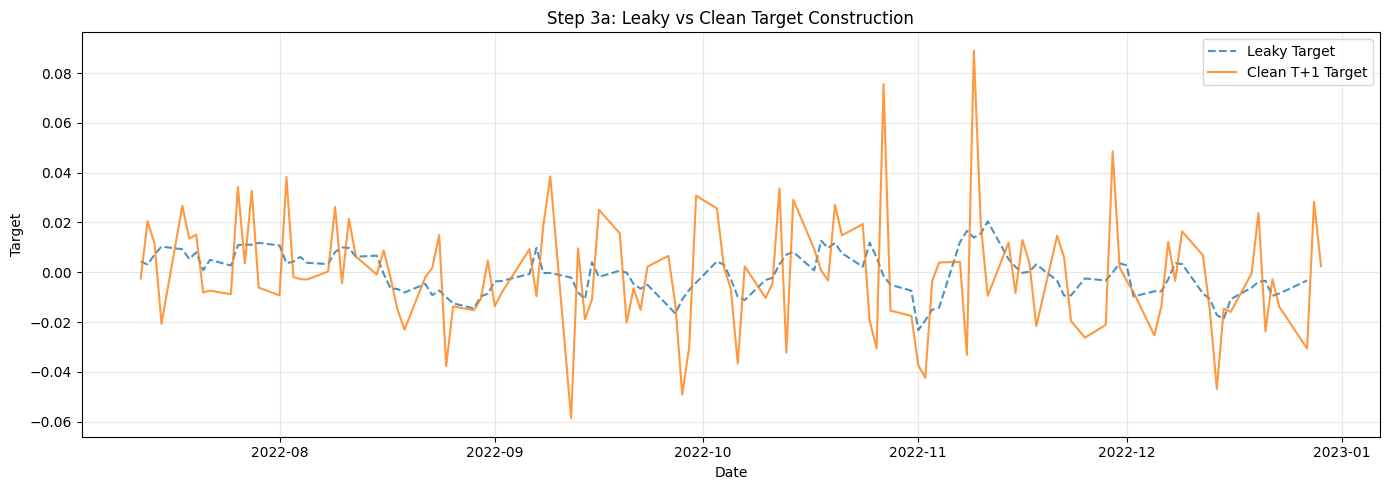

In [ ]:
print("=== Step 3a. Target Transformation and Leakage Audit ===")

clean_data = data.copy()
clean_data["Target_Clean"] = clean_data["Return"].shift(-1)
clean_data["Actual_Next_Return"] = clean_data["Target_Clean"]
clean_data = clean_data.dropna(subset=["Target_Clean"]).copy()

print("\n[Target Comparison]")
leaky_alignment = leaky_data["Target_Leaky"].corr(leaky_data["Actual_Next_Return"])
clean_alignment = clean_data["Target_Clean"].corr(clean_data["Actual_Next_Return"])
print(f"- Correlation between leaky target and actual next return: {leaky_alignment:.4f}")
print(f"- Correlation between clean target and actual next return: {clean_alignment:.4f}")
print("\n[Clean Target]")
print("For the clean dataset, Target_Clean is exactly the next-period return, so its correlation with Actual_Next_Return is expected to be 1.0000.")

plot_dates = clean_data.index[-120:]
plt.figure(figsize=(14, 5))
plt.plot(plot_dates, leaky_data.reindex(plot_dates)["Target_Leaky"], label="Leaky Target", linestyle="--", alpha=0.8)
plt.plot(plot_dates, clean_data.loc[plot_dates]["Target_Clean"], label="Clean T+1 Target", alpha=0.8)
plt.title("Step 3a: Leaky vs Clean Target Construction")
plt.xlabel("Date")
plt.ylabel("Target")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation of Results

- The clean target is constructed as the next-period return, so the target at time \(t\) is based only on the return occurring immediately after the information available at time \(t\).

- The correlation of 1.0000 between the clean target and the actual next-period return is therefore expected because the two variables are intentionally defined to represent the same quantity. This result confirms the target construction rather than demonstrating predictive accuracy.

- The second leakage-control mechanism is applied during walk-forward training. Instead of fitting the scaler using the complete dataset, the scaler is fitted separately within each training window and then applied to the corresponding test observations. The changing training-window scaling boundaries demonstrate that future observations are not being used to determine the transformation parameters for earlier training periods.

# Step 3.b & 3.c: Walk-forward backtest alleviating leakage

The same two walk-forward designs are repeated:

- **Step 3b:** 500 training / 500 testing observations.
- **Step 3c:** 500 training / 100 testing observations.

All three models are evaluated. The key difference from Step 2 is that the target is now strictly forward-looking and the scaler is fitted independently inside each training window.



In [ ]:
def run_walk_forward_clean(clean_df, train_size, test_size):
    records, fold_details = [], []
    max_start = len(clean_df) - train_size - test_size
    if max_start < 0:
        raise ValueError("Not enough observations for the requested split.")
    starts = list(range(0, max_start + 1, test_size))

    for fold_no, start in enumerate(starts, start=1):
        train_start, train_end = start, start + train_size
        test_start, test_end = train_end, train_end + test_size
        train_slice = clean_df.iloc[train_start:train_end].copy()
        test_context_start = max(0, test_start - SEQ_LENGTH)
        test_context = clean_df.iloc[test_context_start:test_end].copy()

        # Fit scaler ONLY on training observations.
        scaler = MinMaxScaler()
        scaled_train = scaler.fit_transform(train_slice[["Return"]])
        scaled_test_context = scaler.transform(test_context[["Return"]])

        X_train, y_train = create_sequences(
            scaled_train.flatten(), train_slice["Target_Clean"].values, SEQ_LENGTH
        )
        X_test, y_test, actual_test_returns = create_sequences_with_actual(
            scaled_test_context.flatten(),
            test_context["Target_Clean"].values,
            test_context["Actual_Next_Return"].values,
            SEQ_LENGTH
        )

        # The first generated sequence ends at the final training observation.
        # Remove it so that only test-period targets remain.
        X_test = X_test[1:]
        y_test = y_test[1:]
        actual_test_returns = actual_test_returns[1:]

        if len(X_test) != test_size:
            raise ValueError(
                f"Expected {test_size} test sequences but received {len(X_test)}."
            )

        for model_name in ["MLP", "LSTM", "CNN-GAF"]:
            set_reproducible_seeds(42 + fold_no)
            X_train_model, X_test_model = prepare_inputs_for_model(model_name, X_train, X_test)
            model = build_model_by_name(model_name)
            model.fit(X_train_model, y_train, epochs=WALK_FORWARD_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            predictions = model.predict(X_test_model, verbose=0).flatten()
            records.append({
                "Fold": fold_no, "Model": model_name,
                "Train Start": train_start, "Train End": train_end - 1,
                "Test Start": test_start, "Test End": test_end - 1,
                "Scaler Train Min": float(scaler.data_min_[0]),
                "Scaler Train Max": float(scaler.data_max_[0]),
                **regression_metrics(y_test, predictions),
                **trading_metrics(predictions, actual_test_returns)
            })
        fold_details.append({
            "Fold": fold_no, "Train Start": train_start, "Train End": train_end - 1,
            "Test Start": test_start, "Test End": test_end - 1
        })
    return pd.DataFrame(records), pd.DataFrame(fold_details)

print("=== Step 3b. Walk-forward backtest (Train 500, Test 500) - Cleaned ===")
step3b_df, step3b_folds = run_walk_forward_clean(clean_data, 500, 500)
display(step3b_folds)
display(step3b_df.style.format({
    "Scaler Train Min":"{:.5f}", "Scaler Train Max":"{:.5f}",
    "MSE":"{:.6f}", "MAE":"{:.6f}", "Directional Accuracy":"{:.2%}",
    "Average Cumulative Strategy Return Across Folds":"{:.2%}", "Annualized Sharpe":"{:.3f}",
    "Max Drawdown":"{:.2%}", "Average Daily Strategy Return":"{:.5f}"
}))

print("\n=== Step 3c. Walk-forward backtest (Train 500, Test 100) - Cleaned ===")
step3c_df, step3c_folds = run_walk_forward_clean(clean_data, 500, 100)
display(step3c_folds)
display(step3c_df.style.format({
    "Scaler Train Min":"{:.5f}", "Scaler Train Max":"{:.5f}",
    "MSE":"{:.6f}", "MAE":"{:.6f}", "Directional Accuracy":"{:.2%}",
    "Average Cumulative Strategy Return Across Folds":"{:.2%}", "Annualized Sharpe":"{:.3f}",
    "Max Drawdown":"{:.2%}", "Average Daily Strategy Return":"{:.5f}"
}))

step3_summary = step3c_df.groupby("Model").agg({
    "Directional Accuracy":"mean", "Average Cumulative Strategy Return Across Folds":"mean",
    "Annualized Sharpe":"mean", "Max Drawdown":"mean"
}).reset_index()
print("\nStep 3c average results across folds:")
display(step3_summary.style.format({
    "Directional Accuracy":"{:.2%}", "Average Cumulative Strategy Return Across Folds":"{:.2%}",
    "Annualized Sharpe":"{:.3f}", "Max Drawdown":"{:.2%}"
}))

=== Step 3b. Walk-forward backtest (Train 500, Test 500) - Cleaned ===


,Fold,Train Start,Train End,Test Start,Test End
0,1,0,499,500,999


,Fold,Model,Train Start,Train End,Test Start,Test End,Scaler Train Min,Scaler Train Max,MSE,MAE,Directional Accuracy,Average Cumulative Strategy Return Across Folds,Annualized Sharpe,Max Drawdown,Average Daily Strategy Return
0,1,MLP,0,499,500,999,-0.09961,0.07042,0.000813,0.019219,48.80%,-29.11%,-0.269,-51.31%,-0.00040
1,1,LSTM,0,499,500,999,-0.09961,0.07042,0.000580,0.016677,45.40%,-65.57%,-1.237,-67.66%,-0.00185
2,1,CNN-GAF,0,499,500,999,-0.09961,0.07042,0.000597,0.017053,52.20%,-10.30%,0.043,-46.31%,0.00007



=== Step 3c. Walk-forward backtest (Train 500, Test 100) - Cleaned ===


,Fold,Train Start,Train End,Test Start,Test End
0,1,0,499,500,599
1,2,100,599,600,699
2,3,200,699,700,799
3,4,300,799,800,899
4,5,400,899,900,999
5,6,500,999,1000,1099
6,7,600,1099,1100,1199


,Fold,Model,Train Start,Train End,Test Start,Test End,Scaler Train Min,Scaler Train Max,MSE,MAE,Directional Accuracy,Average Cumulative Strategy Return Across Folds,Annualized Sharpe,Max Drawdown,Average Daily Strategy Return
0,1,MLP,0,499,500,599,-0.09961,0.07042,0.002122,0.030002,48.00%,-22.80%,-0.846,-44.66%,-0.00193
1,1,LSTM,0,499,500,599,-0.09961,0.07042,0.001357,0.025509,37.00%,-50.96%,-2.882,-50.60%,-0.00646
2,1,CNN-GAF,0,499,500,599,-0.09961,0.07042,0.001324,0.025485,47.00%,-17.49%,-0.559,-36.05%,-0.00127
3,2,MLP,100,599,600,699,-0.12865,0.11981,0.001068,0.026196,51.00%,12.26%,0.903,-18.16%,0.00149
4,2,LSTM,100,599,600,699,-0.12865,0.11981,0.000707,0.019673,45.00%,-14.50%,-0.739,-33.71%,-0.00122
5,2,CNN-GAF,100,599,600,699,-0.12865,0.11981,0.004322,0.053853,53.00%,14.23%,1.014,-18.27%,0.00168
6,3,MLP,200,699,700,799,-0.12865,0.11981,0.000627,0.019502,54.00%,-1.91%,0.021,-23.95%,0.00003
7,3,LSTM,200,699,700,799,-0.12865,0.11981,0.000446,0.016418,46.00%,-1.00%,0.090,-18.72%,0.00012
8,3,CNN-GAF,200,699,700,799,-0.12865,0.11981,0.000542,0.018278,51.00%,8.77%,0.798,-18.76%,0.00106
9,4,MLP,300,799,800,899,-0.12865,0.11981,0.000249,0.012310,56.00%,8.18%,1.005,-14.40%,0.00088



Step 3c average results across folds:


,Model,Directional Accuracy,Average Cumulative Strategy Return Across Folds,Annualized Sharpe,Max Drawdown
0,CNN-GAF,50.86%,2.23%,0.269,-19.43%
1,LSTM,48.43%,-5.42%,-0.057,-22.76%
2,MLP,50.14%,-5.12%,-0.177,-25.48%


### Interpretation of Results

- The clean 500/100 walk-forward experiment provides seven non-anchored out-of-sample test periods and therefore provides a broader assessment of performance stability than the single 500/500 fold.

- Average directional accuracy is 50.14% for the MLP, 48.43% for the LSTM, and 50.86% for the CNN-GAF. These values are all close to the 50% directional benchmark, so the results do not demonstrate a large and consistent directional forecasting advantage.

- The average cumulative strategy return is -5.12% for the MLP, -5.42% for the LSTM, and +2.23% for the CNN-GAF. The corresponding average annualized Sharpe ratios are -0.177, -0.057, and 0.269.

- The positive CNN-GAF result should be interpreted cautiously because performance varies across the seven individual folds. The presence of some profitable test periods does not by itself establish a persistent trading advantage.

- Compared with the deliberately leaky Step 2 results, the leakage-reduced results are generally less favorable for the CNN-GAF, although the changes are not uniform across all three architectures. This indicates that the effect of leakage is model- and period-dependent.

# Step 3.d: Compare the results of the backtests

This section directly compares the leaky and leakage-reduced experiments. The purpose is to determine whether removing the deliberately introduced leakage changes the apparent predictive and trading performance of the models.

The comparison should be interpreted as evidence from this particular sample rather than as proof that information leakage always produces the same magnitude of performance distortion.

=== Step 3d. Overall Walk-forward Comparison ===


,Experiment,Model,Directional_Accuracy,Avg_Cumulative_Strategy_Return,Avg_Annualized_Sharpe,Avg_Max_Drawdown
0,Step 2a: Leaky 500/500,CNN-GAF,51.80%,-23.73%,-0.173,-46.04%
1,Step 2a: Leaky 500/500,LSTM,50.80%,-27.39%,-0.236,-61.66%
2,Step 2a: Leaky 500/500,MLP,47.80%,-25.63%,-0.206,-48.55%
3,Step 2b: Leaky 500/100,CNN-GAF,53.29%,10.03%,1.079,-18.29%
4,Step 2b: Leaky 500/100,LSTM,49.43%,-4.93%,0.056,-25.75%
5,Step 2b: Leaky 500/100,MLP,47.29%,-5.33%,-0.287,-24.57%
6,Step 3b: Clean 500/500,CNN-GAF,52.20%,-10.30%,0.043,-46.31%
7,Step 3b: Clean 500/500,LSTM,45.40%,-65.57%,-1.237,-67.66%
8,Step 3b: Clean 500/500,MLP,48.80%,-29.11%,-0.269,-51.31%
9,Step 3c: Clean 500/100,CNN-GAF,50.86%,2.23%,0.269,-19.43%



[Step 2b vs Step 3c — Directional Accuracy]


,Leaky 500/100 Accuracy,Clean 500/100 Accuracy,Change After Leakage Mitigation
Model,,,
CNN-GAF,53.29%,50.86%,-2.43%
LSTM,49.43%,48.43%,-1.00%
MLP,47.29%,50.14%,+2.86%


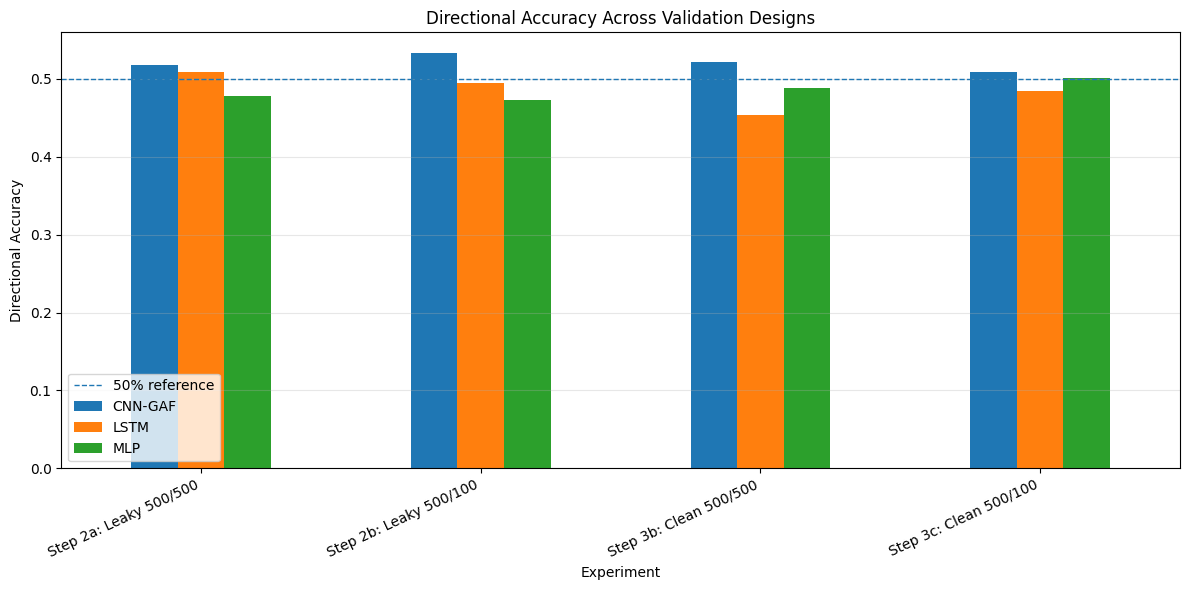


Interpretation guidance: a decline after leakage mitigation is evidence consistent with leakage having inflated apparent performance. It should not be described as proof of causality from this finite, noisy sample alone.


In [ ]:
def summarize_experiment(df, experiment_name):
    return (
        df.groupby("Model")
        .agg(
            Directional_Accuracy=("Directional Accuracy", "mean"),
            Avg_Cumulative_Strategy_Return=("Average Cumulative Strategy Return Across Folds", "mean"),
            Avg_Annualized_Sharpe=("Annualized Sharpe", "mean"),
            Avg_Max_Drawdown=("Max Drawdown", "mean")
        )
        .reset_index()
        .assign(Experiment=experiment_name)
        .loc[:, ["Experiment", "Model", "Directional_Accuracy", "Avg_Cumulative_Strategy_Return", "Avg_Annualized_Sharpe", "Avg_Max_Drawdown"]]
    )

comparison = pd.concat([
    summarize_experiment(step2a_df, "Step 2a: Leaky 500/500"),
    summarize_experiment(step2b_df, "Step 2b: Leaky 500/100"),
    summarize_experiment(step3b_df, "Step 3b: Clean 500/500"),
    summarize_experiment(step3c_df, "Step 3c: Clean 500/100")
], ignore_index=True)

print("=== Step 3d. Overall Walk-forward Comparison ===")
display(comparison.style.format({
    "Directional_Accuracy":"{:.2%}",
    "Avg_Cumulative_Strategy_Return":"{:.2%}",
    "Avg_Annualized_Sharpe":"{:.3f}",
    "Avg_Max_Drawdown":"{:.2%}"
}))

leaky_500_100 = step2b_df.groupby("Model")["Directional Accuracy"].mean().rename("Leaky 500/100 Accuracy")
clean_500_100 = step3c_df.groupby("Model")["Directional Accuracy"].mean().rename("Clean 500/100 Accuracy")
accuracy_comparison = pd.concat([leaky_500_100, clean_500_100], axis=1)
accuracy_comparison["Change After Leakage Mitigation"] = accuracy_comparison["Clean 500/100 Accuracy"] - accuracy_comparison["Leaky 500/100 Accuracy"]

print("\n[Step 2b vs Step 3c — Directional Accuracy]")
display(accuracy_comparison.style.format({
    "Leaky 500/100 Accuracy":"{:.2%}",
    "Clean 500/100 Accuracy":"{:.2%}",
    "Change After Leakage Mitigation":"{:+.2%}"
}))

plot_df = comparison.pivot(index="Experiment", columns="Model", values="Directional_Accuracy")
ax = plot_df.plot(kind="bar", figsize=(12, 6))
ax.axhline(0.50, linestyle="--", linewidth=1, label="50% reference")
ax.set_title("Directional Accuracy Across Validation Designs")
ax.set_xlabel("Experiment")
ax.set_ylabel("Directional Accuracy")
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation guidance: a decline after leakage mitigation is evidence consistent with leakage having inflated apparent performance. It should not be described as proof of causality from this finite, noisy sample alone.")

### Interpretation of Results

- The comparison between the deliberately leaky and leakage-reduced 500/100 walk-forward experiments shows that the effect of leakage mitigation is not uniform across the three architectures.

- For the CNN-GAF, average directional accuracy decreases from 53.29% under the leaky validation design to 50.86% after leakage mitigation, a decline of 2.43 percentage points. The LSTM decreases from 49.43% to 48.43%, a decline of 1.00 percentage point. In contrast, the MLP increases from 47.29% to 50.14%, an increase of 2.86 percentage points.

- The trading results also do not change uniformly. For the CNN-GAF, the average cumulative strategy return decreases from 10.03% in the leaky 500/100 experiment to 2.23% after leakage mitigation. For the LSTM, the result changes from -4.93% to -5.42%, while the MLP changes from -5.33% to -5.12%.

- The results are consistent with leakage affecting measured model and trading performance, but they do not show a uniform inflation of performance across all architectures. In this sample, leakage mitigation reduces the apparent performance of the CNN-GAF, while the MLP shows a small improvement in directional accuracy and strategy return.

- The 500/500 comparison also shows that leakage mitigation does not simply make every result worse. For example, the CNN-GAF strategy return improves from -23.73% in the leaky experiment to -10.30% in the cleaned experiment, whereas the LSTM becomes substantially more negative. This further demonstrates that the effect of leakage is model- and test-period-dependent.

Overall, the results do not support the conclusion that leakage alone explains all apparent overfitting. Instead, they show that validation design can materially affect measured performance and that conclusions about robustness should be based on multiple leakage-aware walk-forward periods rather than a single backtest.